# **Лабораторная работа №8**

Определение частот трезвучия в аудиосигнале. Декодирование DTMF сигналов по курсу Цифровая обработка сигналов

Выполнила: Ходжаметова М. И., группа: М4121

# Импорты и константы (таблица трезвучий)

In [20]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import stft, find_peaks

F0_REF = 130.82  # До малой октавы (C3)
TRIADS = {
    # Major
    "До мажор":        (0, 4, 7),
    "До диез мажор":   (1, 5, 8),
    "Ре мажор":        (2, 6, 9),
    "Ре диез мажор":   (3, 7, 10),
    "Ми мажор":        (4, 8, 11),
    "Фа мажор":        (5, 9, 12),
    "Фа диез мажор":   (6, 10, 13),
    "Соль диез мажор": (8, 12, 15),
    "Ля диез мажор":   (10, 14, 17),
    # Minor
    "До диез минор":   (1, 4, 8),
    "Ре минор":        (2, 5, 9),
    "Ре диез минор":   (3, 6, 10),
    "Ми минор":        (4, 7, 11),
    "Фа диез минор":   (6, 9, 13),
    "Соль диез минор": (8, 11, 15),
    "Ля минор":        (9, 13, 16),
    "Си минор":        (11, 14, 18),
}

def hz_to_semitone(f_hz, f0=F0_REF):
    return int(np.round(12.0 * np.log2(f_hz / f0)))

def semitone_to_hz(n, f0=F0_REF):
    return float(f0 * (2.0 ** (n / 12.0)))

def match_triad_by_semitones(freqs_hz):
    semis = sorted(hz_to_semitone(f) for f in freqs_hz)
    semis_t = tuple(semis)
    for name, tri in TRIADS.items():
        if tuple(sorted(tri)) == semis_t:
            return name, semis
    # иногда оценка может оказаться на октаву выше/ниже
    candidates = set()
    for a in [0, -12]:
        for b in [0, -12]:
            for c in [0, -12]:
                candidates.add(tuple(sorted([semis[0]+a, semis[1]+b, semis[2]+c])))
    for s2 in candidates:
        for name, tri in TRIADS.items():
            if tuple(sorted(tri)) == s2:
                return name, list(s2)
    return None, semis

# Загрузка и выбор “стационарного” участка

In [21]:
def load_segment(path, fs_expected=16000, t_start=0.20, t_stop=3.20):
    x, sr = sf.read(path)
    if sr != fs_expected:
        raise ValueError(f"Ожидалась Fs={fs_expected}, а в файле Fs={sr}")
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float64)
    # Нормализация
    x = x / (np.max(np.abs(x)) + 1e-12)
    i0 = int(t_start * sr)
    i1 = int(t_stop * sr)
    xseg = x[i0:i1]
    return x, xseg, sr

wav_path = "/content/DTLab12.wav"
x, xseg, fs = load_segment(wav_path, fs_expected=16000, t_start=0.20, t_stop=3.20)

# Усреднённый спектр

In [22]:
def average_spectrum_stft(xseg, fs, nperseg=8192, nfft=32768, overlap=0.75):
    noverlap = int(overlap * nperseg)
    f, t, Z = stft(
        xseg, fs=fs, window="hann",
        nperseg=nperseg, noverlap=noverlap,
        nfft=nfft, boundary=None, padded=False
    )
    mag = np.abs(Z)
    M = np.median(mag, axis=1)  # усреднение (медиана) по времени
    M_db = 20*np.log10(M + 1e-12)
    return f, M, M_db

f, M, M_db = average_spectrum_stft(xseg, fs, nperseg=8192, nfft=32768, overlap=0.75)

# Поиск пиков

In [23]:
def find_spectral_peaks(f, M_db, fmin=30, fmax=6000, rel_db=45, min_distance_hz=2.0):
    idx = np.where((f >= fmin) & (f <= fmax))[0]
    f2 = f[idx]
    S2 = M_db[idx]
    thr = S2.max() - rel_db
    df = f2[1] - f2[0]
    distance = max(1, int(min_distance_hz / df))
    peaks, props = find_peaks(S2, height=thr, distance=distance)
    peak_freqs = f2[peaks]
    peak_vals_db = S2[peaks]
    return peak_freqs, peak_vals_db, (f2, S2, thr)

peak_freqs, peak_vals_db, aux = find_spectral_peaks(
    f, M_db, fmin=30, fmax=6000, rel_db=45, min_distance_hz=2.0
)

# Оценка трёх F0

In [24]:
def estimate_triad_f0s(peak_freqs, peak_vals_db,
                      cand_min=90.0, cand_max=800.0, cand_step=0.5,
                      K=10, bw_hz=2.0,
                      suppress_tol_hz=10.0, suppress_max_mult=8):
    cand = np.arange(cand_min, cand_max + 1e-9, cand_step)
    # уммирую “вклад” пиков, попавших в окно +-bw_hz
    def A(freq):
        m = np.abs(peak_freqs - freq) <= bw_hz
        # перевод dB -> линейно для суммирования
        return float(np.sum(10**(peak_vals_db[m]/20.0)))
    scores = np.zeros_like(cand, dtype=np.float64)
    for i, f0 in enumerate(cand):
        s = 0.0
        for k in range(1, K+1):
            s += (1.0/k) * A(k*f0)
        scores[i] = s
    found = []
    scores_work = scores.copy()
    def suppress(f0):
        for mult in range(1, suppress_max_mult+1):
            ff = mult*f0
            scores_work[np.abs(cand-ff) < suppress_tol_hz] = 0.0
        scores_work[np.abs(cand-0.5*f0) < suppress_tol_hz] = 0.0
    for _ in range(3):
        j = int(np.argmax(scores_work))
        f0 = float(cand[j])
        found.append(f0)
        suppress(f0)
    return sorted(found), cand, scores

triad_f0s, cand, scores = estimate_triad_f0s(
    peak_freqs, peak_vals_db,
    cand_min=90.0, cand_max=800.0, cand_step=0.5,
    K=10, bw_hz=2.0,
    suppress_tol_hz=10.0, suppress_max_mult=8
)

# Распознавание трезвучия +  результат

In [25]:
triad_name, semis = match_triad_by_semitones(triad_f0s)
quant_freqs = [semitone_to_hz(n) for n in semis]

print("Оценённые частоты (Гц):", [round(v, 2) for v in triad_f0s])
print("Номера полутонов относительно 130.82 Гц:", semis)
if triad_name is None:
    print("Трезвучие по таблице не сопоставилось.")
else:
    print("Определённая тональность:", triad_name)
print("Квантизованные частоты (Гц):", [round(v, 2) for v in quant_freqs])

Оценённые частоты (Гц): [184.5, 217.0, 273.0]
Номера полутонов относительно 130.82 Гц: [6, 9, 13]
Определённая тональность: Фа диез минор
Квантизованные частоты (Гц): [185.01, 220.01, 277.2]


# Визуализация

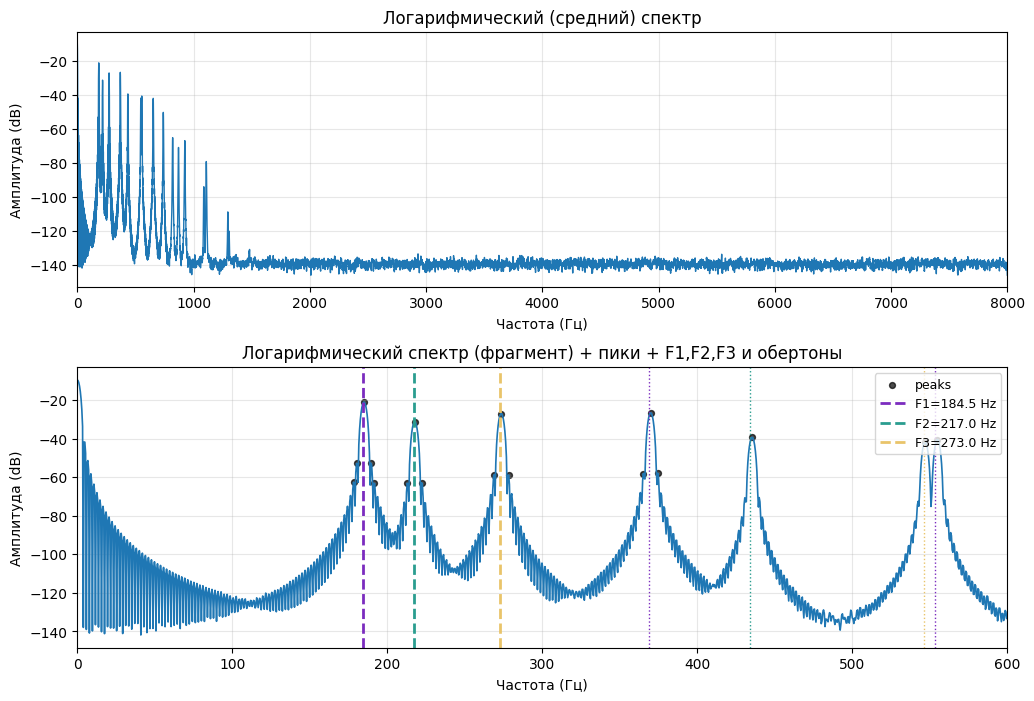

In [27]:
def plot_solution(f, M_db, peak_freqs, peak_vals_db, triad_f0s,
                  zoom_max_hz=600, title_prefix=""):
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.1], hspace=0.30)
    # Полный спектр
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(f, M_db, lw=1)
    ax1.set_title(f"{title_prefix}Логарифмический (средний) спектр")
    ax1.set_xlabel("Частота (Гц)")
    ax1.set_ylabel("Амплитуда (dB)")
    ax1.set_xlim(0, f.max())
    ax1.grid(True, alpha=0.3)
    # Фрагмент + пики и подтверждение обертонами
    ax2 = fig.add_subplot(gs[1, 0])
    m = (f >= 0) & (f <= zoom_max_hz)
    ax2.plot(f[m], M_db[m], lw=1.2)
    ax2.set_title("Логарифмический спектр (фрагмент) + пики + F1,F2,F3 и обертоны")
    ax2.set_xlabel("Частота (Гц)")
    ax2.set_ylabel("Амплитуда (dB)")
    ax2.set_xlim(0, zoom_max_hz)
    ax2.grid(True, alpha=0.3)
    # пики
    pm = peak_freqs <= zoom_max_hz
    ax2.scatter(peak_freqs[pm], peak_vals_db[pm], s=18, c="k", alpha=0.7, label="peaks")
    # линии для F1,F2,F3
    colors = ["#7B2CBF", "#2A9D8F", "#E9C46A"]
    for i, f0 in enumerate(triad_f0s):
        c = colors[i % len(colors)]
        ax2.axvline(f0, color=c, ls="--", lw=2, label=f"F{i+1}={f0:.1f} Hz")
        # обертоны
        for k in range(2, 7):
            fk = k * f0
            if fk <= zoom_max_hz:
                ax2.axvline(fk, color=c, ls=":", lw=1)
    ax2.legend(loc="upper right", fontsize=9)
    plt.show()

plot_solution(f, M_db, peak_freqs, peak_vals_db, triad_f0s,
              zoom_max_hz=600, title_prefix="")